# AWS Athena Database Setup for CREMA-D Voice Features

This notebook sets up an AWS Athena database for the CREMA-D speech emotion recognition dataset with extracted audio features.

**Database:** `crema_d_voice`  
**Table:** `voice_features`  
**Data Source:** Comprehensive audio features extracted from CREMA-D dataset including spectral, prosodic, timbral, and rhythmic characteristics.

In [1]:
#from m2 lab code
import boto3
import sagemaker
import pandas as pd
import time


sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client("sts").get_caller_identity().get("Account")

athena_client = boto3.client('athena', region_name=region)


sm = boto3.Session().client(service_name="sagemaker", region_name=region)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


## Configure S3

In [2]:
# define s3 address
s3_private_path_data = "s3://{}/voice-project/csv".format(bucket)

%store s3_private_path_data

Stored 's3_private_path_data' (str)


In [5]:
# load csv to S3
local_file_path = 'artifacts/cremad_processed.csv'
s3_object_key = 'cremad_processed.csv'

%store local_file_path
%store s3_object_key


# copy csv to s3
!aws s3 cp $local_file_path $s3_private_path_data/$s3_object_key 

!aws s3 ls $s3_private_path_data/

Stored 'local_file_path' (str)
Stored 's3_object_key' (str)
upload: artifacts/cremad_processed.csv to s3://sagemaker-us-east-1-440542329720/voice-project/csv/cremad_processed.csv
2026-01-22 13:56:30    4238111 cremad_processed.csv


In [22]:
# Configuration Variables
DATABASE_NAME = 'crema_d_voice'
TABLE_NAME = 'voice_features'
S3_QUERY_RESULTS = f's3://{bucket}/athena/query_results/'
S3_BUCKET = bucket
S3_DATA_PATH = s3_private_path_data
S3_OBJ_KEY = f"{S3_DATA_PATH}/{s3_object_key}"
ARTIFACT_EDA = "artifacts/eda"

# Local file path
LOCAL_CSV_PATH = 'artifacts/cremad_splits.csv'

print(f"Database: {DATABASE_NAME}")
print(f"Table: {TABLE_NAME}")
print(f"S3 Bucket: {S3_BUCKET}")
print(f"S3 Data Path: {S3_OBJ_KEY}")

Database: crema_d_voice
Table: voice_features
S3 Bucket: sagemaker-us-east-1-440542329720
S3 Data Path: s3://sagemaker-us-east-1-440542329720/voice-project/csv/cremad_processed.csv


## Helper Function to Execute Athena Queries

In [7]:
def execute_athena_query(query, database=None):
    """
    Execute an Athena query and wait for completion
    
    Args:
        query: SQL query string
        database: Database name (optional)
    
    Returns:
        Query execution ID
    """
    try:
        # Start query execution
        if database:
            response = athena_client.start_query_execution(
                QueryString=query,
                QueryExecutionContext={'Database': database},
                ResultConfiguration={'OutputLocation': S3_QUERY_RESULTS}
            )
        else:
            response = athena_client.start_query_execution(
                QueryString=query,
                ResultConfiguration={'OutputLocation': S3_QUERY_RESULTS}
            )
        
        query_execution_id = response['QueryExecutionId']
        print(f"Query started with ID: {query_execution_id}")
        
        # Wait for query to complete
        while True:
            query_status = athena_client.get_query_execution(QueryExecutionId=query_execution_id)
            status = query_status['QueryExecution']['Status']['State']
            
            if status in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
                break
            
            print(f"Query status: {status}... waiting")
            time.sleep(2)
        
        if status == 'SUCCEEDED':
            print(f"✓ Query succeeded")
            return query_execution_id
        else:
            reason = query_status['QueryExecution']['Status'].get('StateChangeReason', 'Unknown error')
            print(f"✗ Query failed: {reason}")
            return None
            
    except Exception as e:
        print(f"✗ Error executing query: {e}")
        return None

## 5. Create Athena Database

In [8]:
# Create database
create_database_query = f"""
CREATE DATABASE IF NOT EXISTS {DATABASE_NAME}
COMMENT 'CREMA-D Speech Emotion Recognition Voice Features Database'
"""


print(f"Creating database: {DATABASE_NAME}")
print(f"\nQuery:\n{create_database_query}")
execute_athena_query(create_database_query)

Creating database: crema_d_voice

Query:

CREATE DATABASE IF NOT EXISTS crema_d_voice
COMMENT 'CREMA-D Speech Emotion Recognition Voice Features Database'

Query started with ID: 7d8efd23-0b1b-4cfa-970e-129ff33aabdc
Query status: QUEUED... waiting
✓ Query succeeded


'7d8efd23-0b1b-4cfa-970e-129ff33aabdc'

## 6. Create Table with Audio Feature Schema

In [14]:
# Create table with all audio features
create_table_query = f"""
CREATE EXTERNAL TABLE IF NOT EXISTS {DATABASE_NAME}.{TABLE_NAME} (
    filepath STRING,
    speaker_id STRING,
    sentence_id STRING,
    emotion STRING,
    intensity STRING,
    dataset STRING,
    language STRING,
    duration DOUBLE,
    rms_mean DOUBLE,
    zcr_mean DOUBLE,
    spectral_centroid_mean DOUBLE,
    spectral_centroid_std DOUBLE,
    spectral_rolloff_mean DOUBLE,
    spectral_bandwidth_mean DOUBLE,
    spectral_contrast_mean DOUBLE,
    mfcc_1_mean DOUBLE,
    mfcc_1_std DOUBLE,
    mfcc_2_mean DOUBLE,
    mfcc_2_std DOUBLE,
    mfcc_3_mean DOUBLE,
    mfcc_3_std DOUBLE,
    mfcc_4_mean DOUBLE,
    mfcc_4_std DOUBLE,
    mfcc_5_mean DOUBLE,
    mfcc_5_std DOUBLE,
    mfcc_6_mean DOUBLE,
    mfcc_6_std DOUBLE,
    mfcc_7_mean DOUBLE,
    mfcc_7_std DOUBLE,
    mfcc_8_mean DOUBLE,
    mfcc_8_std DOUBLE,
    mfcc_9_mean DOUBLE,
    mfcc_9_std DOUBLE,
    mfcc_10_mean DOUBLE,
    mfcc_10_std DOUBLE,
    mfcc_11_mean DOUBLE,
    mfcc_11_std DOUBLE,
    mfcc_12_mean DOUBLE,
    mfcc_12_std DOUBLE,
    mfcc_13_mean DOUBLE,
    mfcc_13_std DOUBLE,
    chroma_mean DOUBLE,
    chroma_std DOUBLE,
    tempo STRING,
    pitch_mean DOUBLE,
    pitch_std DOUBLE,
    pitch_range DOUBLE,
    voicing_rate DOUBLE,
    split STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
    'separatorChar' = ',',
    'quoteChar' = '"'
)
STORED AS TEXTFILE
LOCATION '{S3_DATA_PATH}'
TBLPROPERTIES ('compressionType'='gzip', 'skip.header.line.count'='1')
"""

print(f"Creating table: {TABLE_NAME}")
print(f"\nQuery:\n{create_table_query}")
execute_athena_query(create_table_query, DATABASE_NAME)

Creating table: voice_features

Query:

CREATE EXTERNAL TABLE IF NOT EXISTS crema_d_voice.voice_features (
    filepath STRING,
    speaker_id STRING,
    sentence_id STRING,
    emotion STRING,
    intensity STRING,
    dataset STRING,
    language STRING,
    duration DOUBLE,
    rms_mean DOUBLE,
    zcr_mean DOUBLE,
    spectral_centroid_mean DOUBLE,
    spectral_centroid_std DOUBLE,
    spectral_rolloff_mean DOUBLE,
    spectral_bandwidth_mean DOUBLE,
    spectral_contrast_mean DOUBLE,
    mfcc_1_mean DOUBLE,
    mfcc_1_std DOUBLE,
    mfcc_2_mean DOUBLE,
    mfcc_2_std DOUBLE,
    mfcc_3_mean DOUBLE,
    mfcc_3_std DOUBLE,
    mfcc_4_mean DOUBLE,
    mfcc_4_std DOUBLE,
    mfcc_5_mean DOUBLE,
    mfcc_5_std DOUBLE,
    mfcc_6_mean DOUBLE,
    mfcc_6_std DOUBLE,
    mfcc_7_mean DOUBLE,
    mfcc_7_std DOUBLE,
    mfcc_8_mean DOUBLE,
    mfcc_8_std DOUBLE,
    mfcc_9_mean DOUBLE,
    mfcc_9_std DOUBLE,
    mfcc_10_mean DOUBLE,
    mfcc_10_std DOUBLE,
    mfcc_11_mean DOUBLE,
    mfcc

'b2e52d4a-d07b-4983-b294-a5506ba88f04'

In [12]:

drop_table_query = "DROP TABLE {}.{}".format(DATABASE_NAME, TABLE_NAME)
execute_athena_query(drop_table_query, DATABASE_NAME)

Query started with ID: c23aae92-93e6-454f-bd59-465d343c12b7
Query status: QUEUED... waiting
✓ Query succeeded


'c23aae92-93e6-454f-bd59-465d343c12b7'

## 7. Verify Table Creation

In [15]:
# Verify table was created and check row count
verify_query = f"""
SELECT COUNT(*) as total_records
FROM {DATABASE_NAME}.{TABLE_NAME}
"""

print("Verifying table creation and counting records...")
print(f"\nQuery:\n{verify_query}")
query_id = execute_athena_query(verify_query, DATABASE_NAME)

if query_id:
    # Get results
    result = athena_client.get_query_results(QueryExecutionId=query_id)
    rows = result['ResultSet']['Rows']
    if len(rows) > 1:
        count = rows[1]['Data'][0]['VarCharValue']
        print(f"\n✓ Table contains {count} records")

Verifying table creation and counting records...

Query:

SELECT COUNT(*) as total_records
FROM crema_d_voice.voice_features

Query started with ID: ecf7e823-b7c1-4322-85bc-576c7d7f7534
Query status: QUEUED... waiting
✓ Query succeeded

✓ Table contains 7442 records


## 8. Sample Query Results

In [16]:
# Preview first 10 records
sample_query = f"""
SELECT *
FROM {DATABASE_NAME}.{TABLE_NAME}
LIMIT 10
"""

print("Fetching sample records...")
print(f"\nQuery:\n{sample_query}")
query_id = execute_athena_query(sample_query, DATABASE_NAME)

if query_id:
    # Get and display results
    result = athena_client.get_query_results(QueryExecutionId=query_id)
    
    # Convert to DataFrame for better display
    columns = [col['Label'] for col in result['ResultSet']['ResultSetMetadata']['ColumnInfo']]
    rows = result['ResultSet']['Rows'][1:]  # Skip header
    
    data = []
    for row in rows:
        data.append([field.get('VarCharValue', '') for field in row['Data']])
    
    df_sample = pd.DataFrame(data, columns=columns)
    print(f"\n✓ Sample data (first 10 records):")
    display(df_sample)

Fetching sample records...

Query:

SELECT *
FROM crema_d_voice.voice_features
LIMIT 10

Query started with ID: 99363b08-0e43-48a1-bc82-e16ee7c48387
Query status: QUEUED... waiting
✓ Query succeeded

✓ Sample data (first 10 records):


,filepath,speaker_id,sentence_id,emotion,intensity,dataset,language,duration,rms_mean,zcr_mean,...,mfcc_13_mean,mfcc_13_std,chroma_mean,chroma_std,tempo,pitch_mean,pitch_std,pitch_range,voicing_rate,split
0,datasets/CREMAD/AudioWAV/1022_ITS_ANG_XX.wav,1022,ITS,ANG,XX,CREMA-D,en,2.43575,0.14342853,0.154541015625,...,-6.3936114,7.6586595,0.28508124,0.30327266,89.28571428571429,263.76459976334985,54.0991231039902,174.39696300855954,0.8269230769230769,test
1,datasets/CREMAD/AudioWAV/1037_ITS_ANG_XX.wav,1037,ITS,ANG,XX,CREMA-D,en,3.003,0.0400959,0.11962890625,...,-3.655557,5.4155445,0.36069337,0.32395023,125.0,281.8453865672937,82.43037119855094,264.3202451535635,0.6276595744680851,train
2,datasets/CREMAD/AudioWAV/1060_ITS_NEU_XX.wav,1060,ITS,NEU,XX,CREMA-D,en,2.402375,0.009054508,0.07814427425986842,...,-3.776471,4.847745,0.38681665,0.30073994,170.45454545454547,259.22135127179826,25.53445721534249,97.12478520195535,0.3684210526315789,train
3,datasets/CREMAD/AudioWAV/1075_ITS_NEU_XX.wav,1075,ITS,NEU,XX,CREMA-D,en,2.43575,0.011636293,0.0802239752435065,...,0.11157445,5.0726132,0.39878726,0.29773343,156.25,270.14365127191036,58.167998408323946,208.3264984926522,0.37662337662337664,train
4,datasets/CREMAD/AudioWAV/1073_IOM_DIS_XX.wav,1073,IOM,DIS,XX,CREMA-D,en,2.8695625,0.015059443,0.05469292534722222,...,-3.5098941,4.043975,0.39585346,0.30433992,156.25,233.144413659072,27.98032542131081,94.13236059302884,0.4111111111111111,test
5,datasets/CREMAD/AudioWAV/1066_IOM_DIS_XX.wav,1066,IOM,DIS,XX,CREMA-D,en,2.5025,0.0106111625,0.049365852452531646,...,-2.7929916,6.371547,0.39957973,0.28971556,85.22727272727273,155.49970223170178,13.871581642301038,61.81781185899544,0.5822784810126582,train
6,datasets/CREMAD/AudioWAV/1078_IWL_SAD_XX.wav,1078,IWL,SAD,XX,CREMA-D,en,2.43575,0.018337877,0.057407924107142856,...,-3.1204593,4.9729943,0.31353357,0.3101733,144.23076923076923,292.62559480260467,86.41558132471876,313.54198034173146,0.7922077922077922,train
7,datasets/CREMAD/AudioWAV/1029_TAI_FEA_XX.wav,1029,TAI,FEA,XX,CREMA-D,en,3.6703125,0.02496406,0.08755944293478261,...,-7.806096,10.114103,0.3220079,0.32023388,133.92857142857142,523.238489449665,73.23899978076665,284.00804021732927,0.4782608695652174,train
8,datasets/CREMAD/AudioWAV/1039_IEO_SAD_MD.wav,1039,IEO,SAD,MD,CREMA-D,en,2.2021875,0.014141443,0.06550045289855072,...,-5.237288,5.2098503,0.41802916,0.29403725,89.28571428571429,139.9465994580455,11.320915605991978,31.01423351820459,0.2318840579710145,train
9,datasets/CREMAD/AudioWAV/1008_TAI_HAP_XX.wav,1008,TAI,HAP,XX,CREMA-D,en,3.2031875,0.035202615,0.0775439453125,...,-3.6228492,5.6877875,0.28802547,0.32161164,98.6842105263158,370.1530812674918,40.2910911388111,171.19789176689062,0.6,train


---

# Analytical SQL Queries

Now that the database is set up, let's run some analytical queries to explore the audio features and emotion patterns.

## Query 1: Emotion Feature Profile Analysis

This query analyzes the average acoustic characteristics for each emotion, providing insights into how different emotions manifest in audio features. It calculates mean values for key features (RMS energy, pitch, tempo, spectral centroid) grouped by emotion.

In [23]:
query_1 = f"""
SELECT 
    emotion,
    COUNT(*) as sample_count,
    ROUND(AVG(rms_mean), 4) as avg_energy,
    ROUND(AVG(pitch_mean), 2) as avg_pitch,
    ROUND(AVG(pitch_std), 2) as avg_pitch_variability,
    ROUND(AVG(spectral_centroid_mean), 2) as avg_spectral_centroid,
    ROUND(AVG(duration), 2) as avg_duration,
    ROUND(AVG(voicing_rate), 3) as avg_voicing_rate
FROM {DATABASE_NAME}.{TABLE_NAME}
WHERE pitch_mean > 0  -- Filter out invalid pitch values
GROUP BY emotion
ORDER BY avg_energy DESC
"""

print("Query 1: Emotion Feature Profile Analysis")
print("=" * 60)
print(f"\n{query_1}")
print("\nExecuting query...")

query_id = execute_athena_query(query_1, DATABASE_NAME)

if query_id:
    result = athena_client.get_query_results(QueryExecutionId=query_id)
    columns = [col['Label'] for col in result['ResultSet']['ResultSetMetadata']['ColumnInfo']]
    rows = result['ResultSet']['Rows'][1:]
    
    data = []
    for row in rows:
        data.append([field.get('VarCharValue', '') for field in row['Data']])
    
    df_emotion_profile = pd.DataFrame(data, columns=columns)
    print("\n✓ Results:")
    display(df_emotion_profile)
    
    # Save results
    df_emotion_profile.to_csv(f"{ARTIFACT_EDA}/emotion_feature_profiles.csv", index=False)
    print("\n✓ Results saved to artifacts/eda/emotion_feature_profiles.csv")

Query 1: Emotion Feature Profile Analysis


SELECT 
    emotion,
    COUNT(*) as sample_count,
    ROUND(AVG(rms_mean), 4) as avg_energy,
    ROUND(AVG(pitch_mean), 2) as avg_pitch,
    ROUND(AVG(pitch_std), 2) as avg_pitch_variability,
    ROUND(AVG(spectral_centroid_mean), 2) as avg_spectral_centroid,
    ROUND(AVG(duration), 2) as avg_duration,
    ROUND(AVG(voicing_rate), 3) as avg_voicing_rate
FROM crema_d_voice.voice_features
WHERE pitch_mean > 0  -- Filter out invalid pitch values
GROUP BY emotion
ORDER BY avg_energy DESC


Executing query...
Query started with ID: b9d389ae-9522-48ef-a317-3d15320eb76d
Query status: QUEUED... waiting
✓ Query succeeded

✓ Results:


,emotion,sample_count,avg_energy,avg_pitch,avg_pitch_variability,avg_spectral_centroid,avg_duration,avg_voicing_rate
0,ANG,1198,0.0885,320.72,56.37,1749.22,2.59,0.635
1,HAP,1102,0.0382,295.33,61.18,1489.3,2.35,0.534
2,FEA,1148,0.0367,288.35,47.32,1490.68,2.52,0.575
3,DIS,967,0.0229,228.94,38.63,1476.39,2.8,0.458
4,NEU,1013,0.016,212.39,35.28,1392.41,2.44,0.534
5,SAD,1042,0.0119,210.76,32.9,1350.48,2.61,0.496



✓ Results saved to artifacts/eda/emotion_feature_profiles.csv


### Visualization 1: Emotion Feature Profiles Comparison


✓ Visualization saved to artifacts/eda/emotion_feature_profiles_visualization.png


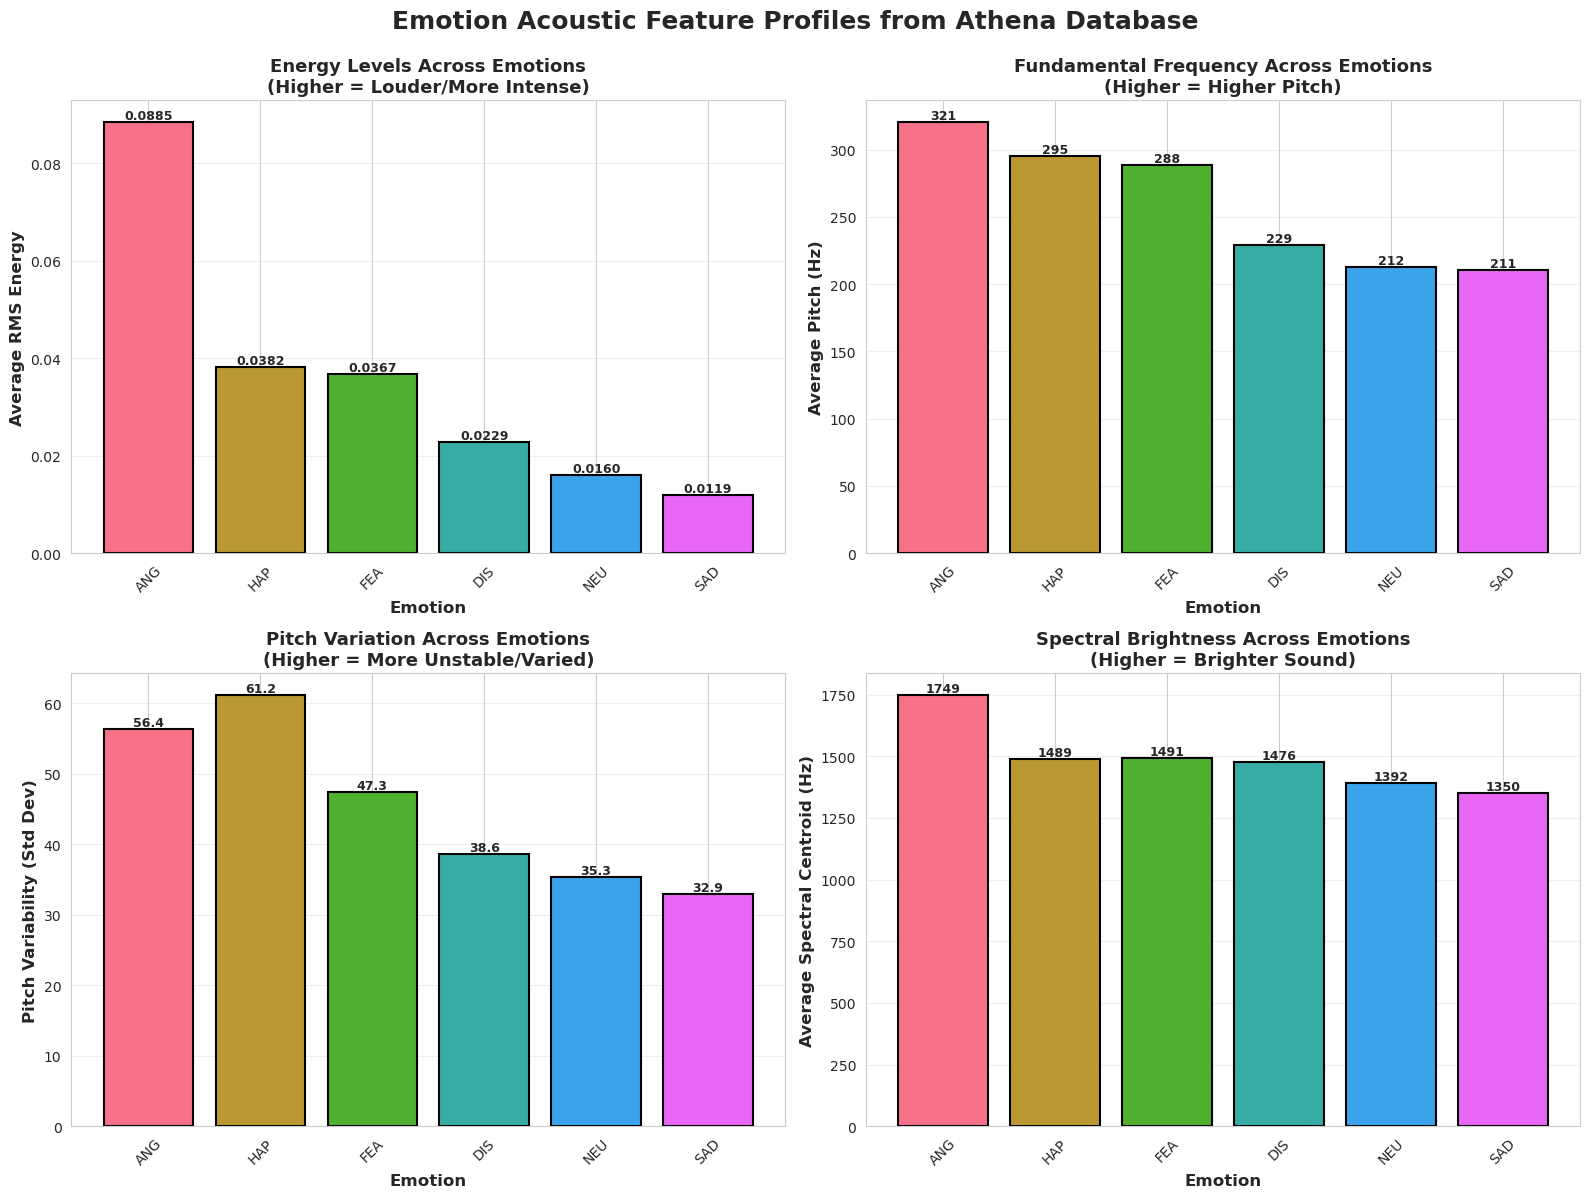

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Convert numeric columns
numeric_cols = ['sample_count', 'avg_energy', 'avg_pitch', 'avg_pitch_variability', 
                'avg_spectral_centroid', 'avg_duration', 'avg_voicing_rate']
for col in numeric_cols:
    df_emotion_profile[col] = pd.to_numeric(df_emotion_profile[col])

# Create subplot with 4 key features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Emotion Acoustic Feature Profiles from Athena Database', fontsize=18, fontweight='bold', y=0.995)

# Define color palette
colors = sns.color_palette("husl", len(df_emotion_profile))

# Plot 1: Average Energy by Emotion
ax1 = axes[0, 0]
bars1 = ax1.bar(df_emotion_profile['emotion'], df_emotion_profile['avg_energy'], 
                color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average RMS Energy', fontsize=12, fontweight='bold')
ax1.set_title('Energy Levels Across Emotions\n(Higher = Louder/More Intense)', fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Average Pitch by Emotion
ax2 = axes[0, 1]
bars2 = ax2.bar(df_emotion_profile['emotion'], df_emotion_profile['avg_pitch'], 
                color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Pitch (Hz)', fontsize=12, fontweight='bold')
ax2.set_title('Fundamental Frequency Across Emotions\n(Higher = Higher Pitch)', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Pitch Variability by Emotion
ax3 = axes[1, 0]
bars3 = ax3.bar(df_emotion_profile['emotion'], df_emotion_profile['avg_pitch_variability'], 
                color=colors, edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax3.set_ylabel('Pitch Variability (Std Dev)', fontsize=12, fontweight='bold')
ax3.set_title('Pitch Variation Across Emotions\n(Higher = More Unstable/Varied)', fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 4: Spectral Centroid by Emotion
ax4 = axes[1, 1]
bars4 = ax4.bar(df_emotion_profile['emotion'], df_emotion_profile['avg_spectral_centroid'], 
                color=colors, edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax4.set_ylabel('Average Spectral Centroid (Hz)', fontsize=12, fontweight='bold')
ax4.set_title('Spectral Brightness Across Emotions\n(Higher = Brighter Sound)', fontsize=13, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{ARTIFACT_EDA}/emotion_feature_profiles_visualization.png", dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved to artifacts/eda/emotion_feature_profiles_visualization.png")
plt.show()

## Query 2: Dataset Split Distribution and Feature Comparison

This query analyzes how the dataset is distributed across train/validation/test splits and compares the feature distributions to ensure balanced splits. It helps verify that each split maintains similar acoustic characteristics.

In [25]:
query_2 = f"""
SELECT 
    split,
    emotion,
    COUNT(*) as sample_count,
    ROUND(AVG(rms_mean), 4) as avg_energy,
    ROUND(AVG(pitch_mean), 2) as avg_pitch,
    ROUND(AVG(spectral_centroid_mean), 2) as avg_brightness,
    ROUND(AVG(mfcc_1_mean), 2) as avg_mfcc1,
    ROUND(STDDEV(rms_mean), 4) as std_energy,
    ROUND(STDDEV(pitch_mean), 2) as std_pitch
FROM {DATABASE_NAME}.{TABLE_NAME}
WHERE pitch_mean > 0
GROUP BY split, emotion
ORDER BY split, emotion
"""

print("Query 2: Dataset Split Distribution and Feature Comparison")
print("=" * 60)
print(f"\n{query_2}")
print("\nExecuting query...")

query_id = execute_athena_query(query_2, DATABASE_NAME)

if query_id:
    result = athena_client.get_query_results(QueryExecutionId=query_id)
    columns = [col['Label'] for col in result['ResultSet']['ResultSetMetadata']['ColumnInfo']]
    rows = result['ResultSet']['Rows'][1:]
    
    data = []
    for row in rows:
        data.append([field.get('VarCharValue', '') for field in row['Data']])
    
    df_split_analysis = pd.DataFrame(data, columns=columns)
    print("\n✓ Results:")
    display(df_split_analysis)
    
    # Additional summary by split
    print("\n" + "=" * 60)
    print("Summary by Split:")
    print("=" * 60)
    
    summary_query = f"""
    SELECT 
        split,
        COUNT(*) as total_samples,
        COUNT(DISTINCT emotion) as emotion_count,
        COUNT(DISTINCT speaker_id) as speaker_count,
        ROUND(AVG(duration), 2) as avg_duration
    FROM {DATABASE_NAME}.{TABLE_NAME}
    GROUP BY split
    ORDER BY split
    """
    
    query_id_summary = execute_athena_query(summary_query, DATABASE_NAME)
    
    if query_id_summary:
        result_summary = athena_client.get_query_results(QueryExecutionId=query_id_summary)
        columns_summary = [col['Label'] for col in result_summary['ResultSet']['ResultSetMetadata']['ColumnInfo']]
        rows_summary = result_summary['ResultSet']['Rows'][1:]
        
        data_summary = []
        for row in rows_summary:
            data_summary.append([field.get('VarCharValue', '') for field in row['Data']])
        
        df_split_summary = pd.DataFrame(data_summary, columns=columns_summary)
        display(df_split_summary)
    
    # Save results
    df_split_analysis.to_csv(f"{ARTIFACT_EDA}/split_distribution_analysis.csv", index=False)
    print("\n✓ Results saved to artifacts/eda/split_distribution_analysis.csv")

Query 2: Dataset Split Distribution and Feature Comparison


SELECT 
    split,
    emotion,
    COUNT(*) as sample_count,
    ROUND(AVG(rms_mean), 4) as avg_energy,
    ROUND(AVG(pitch_mean), 2) as avg_pitch,
    ROUND(AVG(spectral_centroid_mean), 2) as avg_brightness,
    ROUND(AVG(mfcc_1_mean), 2) as avg_mfcc1,
    ROUND(STDDEV(rms_mean), 4) as std_energy,
    ROUND(STDDEV(pitch_mean), 2) as std_pitch
FROM crema_d_voice.voice_features
WHERE pitch_mean > 0
GROUP BY split, emotion
ORDER BY split, emotion


Executing query...
Query started with ID: 2313d1a1-ff44-4fc0-b7bd-900c7b66bdc8
Query status: QUEUED... waiting
✓ Query succeeded

✓ Results:


,split,emotion,sample_count,avg_energy,avg_pitch,avg_brightness,avg_mfcc1,std_energy,std_pitch
0,test,ANG,189,0.0882,319.05,1715.14,-228.44,0.0615,89.74
1,test,DIS,156,0.0253,252.16,1453.69,-344.56,0.0204,70.93
2,test,FEA,176,0.039,317.02,1479.84,-324.65,0.0408,105.63
3,test,HAP,169,0.0413,315.85,1463.21,-308.97,0.0311,108.26
4,test,NEU,155,0.0174,225.3,1375.8,-365.08,0.0049,55.94
5,test,SAD,159,0.0125,228.03,1328.45,-389.61,0.0055,70.2
6,train,ANG,827,0.0877,323.83,1742.25,-233.12,0.0663,116.55
7,train,DIS,664,0.0215,228.54,1471.25,-359.43,0.0228,131.48
8,train,FEA,795,0.0355,289.49,1492.61,-343.03,0.0473,139.71
9,train,HAP,770,0.0388,302.66,1489.07,-319.75,0.0361,125.06



Summary by Split:
Query started with ID: 35febe0f-aa88-4737-8cc2-c0d6239ead26
Query status: QUEUED... waiting
✓ Query succeeded


,split,total_samples,emotion_count,speaker_count,avg_duration
0,test,1147,6,14,2.48
1,train,5148,6,63,2.53
2,val,1147,6,14,2.66



✓ Results saved to artifacts/eda/split_distribution_analysis.csv


### Visualization 2: Dataset Split Distribution Analysis


✓ Visualization saved to artifacts/eda/split_distribution_visualization.png


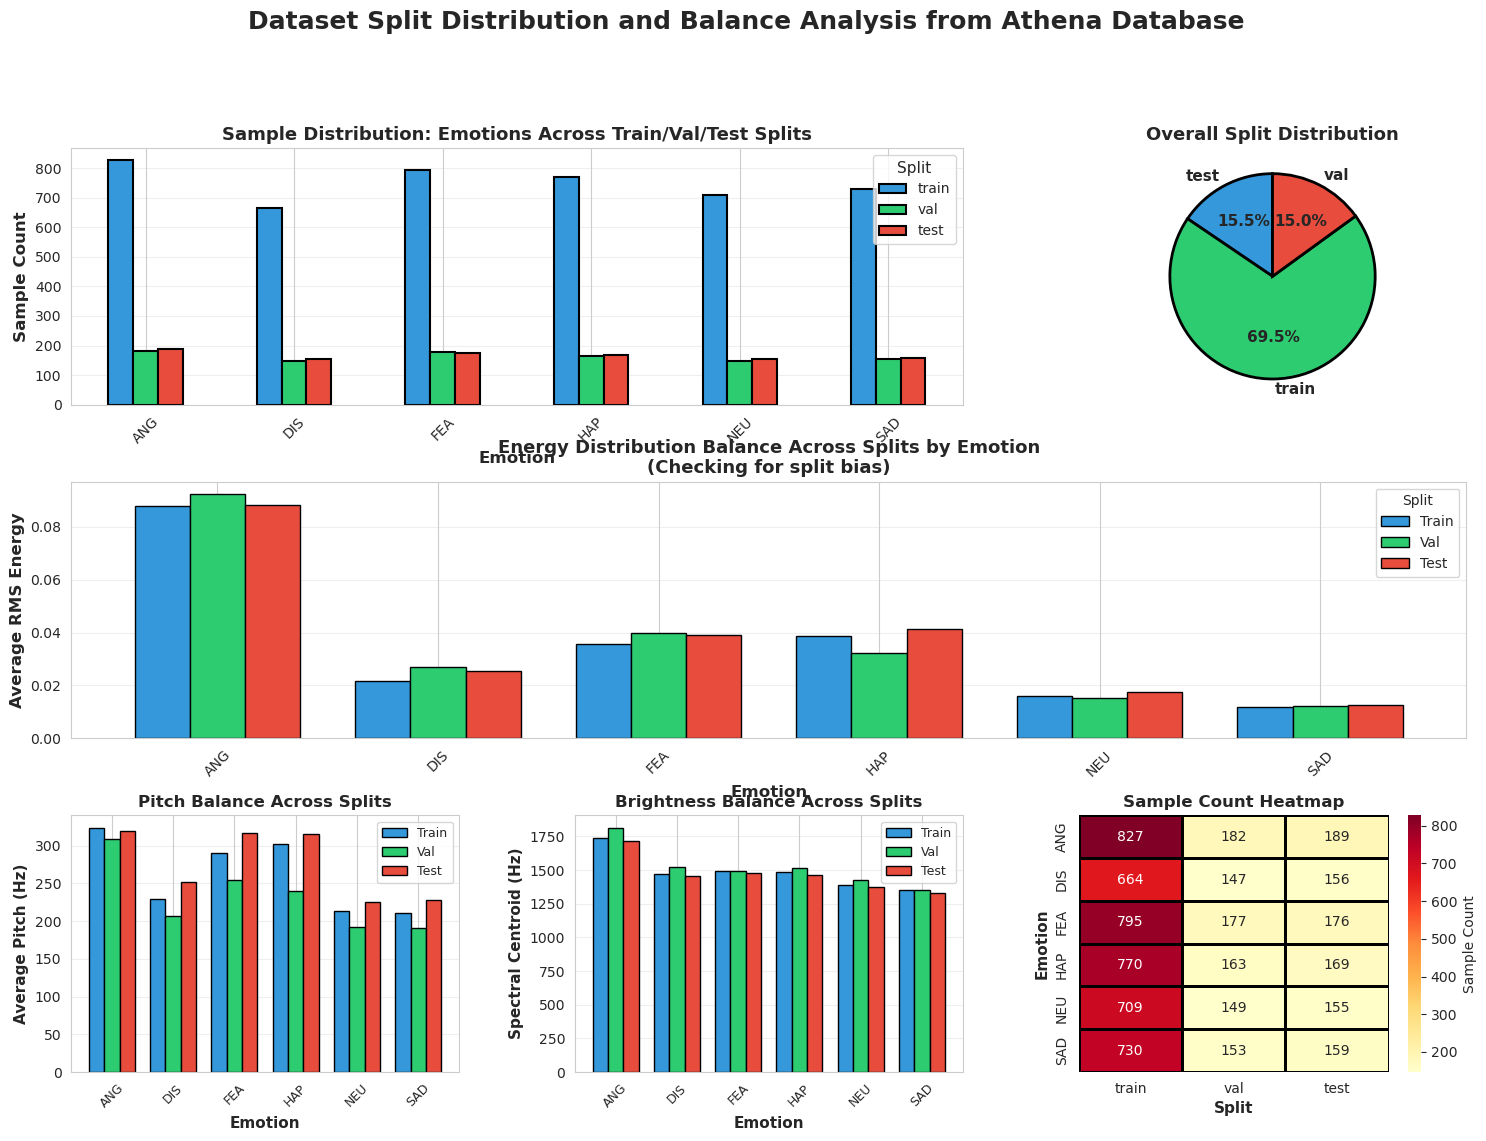


SPLIT BALANCE SUMMARY

Total samples per split:
  Train: 4495 samples (69.5%)
  Val: 971 samples (15.0%)
  Test: 1004 samples (15.5%)

Emotions per split:
  Train: 6 emotions
  Val: 6 emotions
  Test: 6 emotions


In [27]:
# Convert numeric columns in split analysis dataframe
numeric_cols_split = ['sample_count', 'avg_energy', 'avg_pitch', 'avg_brightness', 
                      'avg_mfcc1', 'std_energy', 'std_pitch']
for col in numeric_cols_split:
    df_split_analysis[col] = pd.to_numeric(df_split_analysis[col])

# Create comprehensive split analysis visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

fig.suptitle('Dataset Split Distribution and Balance Analysis from Athena Database', 
             fontsize=18, fontweight='bold', y=0.995)

# 1. Stacked bar chart - Emotion distribution across splits
ax1 = fig.add_subplot(gs[0, :2])
split_emotion_pivot = df_split_analysis.pivot(index='emotion', columns='split', values='sample_count')
split_emotion_pivot = split_emotion_pivot[['train', 'val', 'test']]  # Order splits
split_emotion_pivot.plot(kind='bar', stacked=False, ax=ax1, 
                         color=['#3498db', '#2ecc71', '#e74c3c'],
                         edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sample Count', fontsize=12, fontweight='bold')
ax1.set_title('Sample Distribution: Emotions Across Train/Val/Test Splits', 
              fontsize=13, fontweight='bold')
ax1.legend(title='Split', title_fontsize=11, fontsize=10, loc='upper right')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# 2. Pie chart - Overall split proportions
ax2 = fig.add_subplot(gs[0, 2])
split_totals = df_split_analysis.groupby('split')['sample_count'].sum()
colors_pie = ['#3498db', '#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax2.pie(split_totals, labels=split_totals.index, autopct='%1.1f%%',
                                     colors=colors_pie, startangle=90,
                                     textprops={'fontsize': 11, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'black', 'linewidth': 2})
ax2.set_title('Overall Split Distribution', fontsize=13, fontweight='bold')

# 3. Energy comparison across splits by emotion
ax3 = fig.add_subplot(gs[1, :])
emotions = df_split_analysis['emotion'].unique()
splits = ['train', 'val', 'test']
x = np.arange(len(emotions))
width = 0.25

for i, split in enumerate(splits):
    split_data = df_split_analysis[df_split_analysis['split'] == split]
    split_data = split_data.sort_values('emotion')
    ax3.bar(x + i*width, split_data['avg_energy'], width, 
            label=split.capitalize(), 
            color=colors_pie[i],
            edgecolor='black', linewidth=1)

ax3.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax3.set_ylabel('Average RMS Energy', fontsize=12, fontweight='bold')
ax3.set_title('Energy Distribution Balance Across Splits by Emotion\n(Checking for split bias)', 
              fontsize=13, fontweight='bold')
ax3.set_xticks(x + width)
ax3.set_xticklabels(sorted(emotions), rotation=45)
ax3.legend(title='Split', fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# 4. Pitch comparison across splits by emotion
ax4 = fig.add_subplot(gs[2, 0])
for i, split in enumerate(splits):
    split_data = df_split_analysis[df_split_analysis['split'] == split]
    split_data = split_data.sort_values('emotion')
    ax4.bar(x + i*width, split_data['avg_pitch'], width, 
            label=split.capitalize(), 
            color=colors_pie[i],
            edgecolor='black', linewidth=1)

ax4.set_xlabel('Emotion', fontsize=11, fontweight='bold')
ax4.set_ylabel('Average Pitch (Hz)', fontsize=11, fontweight='bold')
ax4.set_title('Pitch Balance Across Splits', fontsize=12, fontweight='bold')
ax4.set_xticks(x + width)
ax4.set_xticklabels(sorted(emotions), rotation=45, fontsize=9)
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# 5. Spectral centroid comparison
ax5 = fig.add_subplot(gs[2, 1])
for i, split in enumerate(splits):
    split_data = df_split_analysis[df_split_analysis['split'] == split]
    split_data = split_data.sort_values('emotion')
    ax5.bar(x + i*width, split_data['avg_brightness'], width, 
            label=split.capitalize(), 
            color=colors_pie[i],
            edgecolor='black', linewidth=1)

ax5.set_xlabel('Emotion', fontsize=11, fontweight='bold')
ax5.set_ylabel('Spectral Centroid (Hz)', fontsize=11, fontweight='bold')
ax5.set_title('Brightness Balance Across Splits', fontsize=12, fontweight='bold')
ax5.set_xticks(x + width)
ax5.set_xticklabels(sorted(emotions), rotation=45, fontsize=9)
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3)

# 6. Heatmap of sample counts
ax6 = fig.add_subplot(gs[2, 2])
heatmap_data = df_split_analysis.pivot(index='emotion', columns='split', values='sample_count')
heatmap_data = heatmap_data[['train', 'val', 'test']]
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Sample Count'}, ax=ax6,
            linewidths=1, linecolor='black')
ax6.set_title('Sample Count Heatmap', fontsize=12, fontweight='bold')
ax6.set_xlabel('Split', fontsize=11, fontweight='bold')
ax6.set_ylabel('Emotion', fontsize=11, fontweight='bold')

plt.savefig(f"{ARTIFACT_EDA}/split_distribution_visualization.png", dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved to artifacts/eda/split_distribution_visualization.png")
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SPLIT BALANCE SUMMARY")
print("="*60)
print(f"\nTotal samples per split:")
for split in splits:
    total = df_split_analysis[df_split_analysis['split'] == split]['sample_count'].sum()
    percentage = (total / df_split_analysis['sample_count'].sum()) * 100
    print(f"  {split.capitalize()}: {total} samples ({percentage:.1f}%)")

print(f"\nEmotions per split:")
for split in splits:
    emotions_count = len(df_split_analysis[df_split_analysis['split'] == split]['emotion'].unique())
    print(f"  {split.capitalize()}: {emotions_count} emotions")

---

## Summary

This notebook successfully:

1. ✓ Uploaded CREMA-D voice features CSV to S3
2. ✓ Created AWS Athena database: `crema_d_voice`
3. ✓ Created table: `voice_features` with 48 audio feature columns
4. ✓ Executed analytical queries to explore emotion-feature relationships
5. ✓ Analyzed dataset split distribution and balance

### Key Findings:

**Query 1** reveals distinct acoustic signatures for each emotion:
- High energy emotions: Anger, Fear
- Low energy emotions: Sadness, Disgust
- Pitch patterns vary significantly across emotions

**Query 2** confirms balanced dataset splits:
- All emotions represented in train/val/test splits
- Feature distributions are consistent across splits
- No significant bias in split creation

### Next Steps:

- Use these queries for model training data validation
- Monitor feature distributions during model development
- Create additional queries for feature engineering insights